# Processed Data Verification & EDA
This notebook verifies the integrity of the modular Parquet components and performs basic EDA on the engineered technical features.

In [13]:
%load_ext autoreload
%autoreload 2

import os
import sys
# import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Add project root to path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from src.data.data_module import DataModule

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### 1. Load Modular Components via DataModule

In [14]:
PROCESSED_DIR = "../data/processed_market"
dm = DataModule(PROCESSED_DIR)

# Load and join features, targets, and metadata
df = dm.prepare_dataset(components=["technical_features", "targets", "metadata"])
df.sort_index(inplace=True)

print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset loaded: 37727 rows, 32 columns


,TRIX_30_9,VWAP_D,ROC_10,RSI_14,ATRr_14,MFI_14,EFI_13,BBB_5_2.0_2.0,BBP_5_2.0_2.0,KCBe_20_2,...,ER_10,LogRet_5h,LogRet_12h,LogRet_24h,Target_5h_TBM,Open,High,Low,Close,Volume
time,,,,,,,,,,,,,,,,,,,,,
2020-01-07 22:00:00+00:00,-0.000627,1.116562,-0.243405,37.577962,0.000995,32.247139,-0.466083,0.110740,0.610181,1.115972,...,0.467354,0.000628,-0.001823,-0.003424,0.0,1.11519,1.11534,1.11441,1.11476,1150
2020-01-07 23:00:00+00:00,-0.001033,1.116489,-0.019720,43.262676,0.000980,32.058310,-0.174228,0.143852,0.859166,1.115919,...,0.047619,-0.000565,-0.002415,-0.003692,2.0,1.11473,1.11543,1.11464,1.11541,2426
2020-01-08 00:00:00+00:00,-0.001396,1.115983,0.097777,46.945033,0.001021,45.692323,0.198750,0.184745,0.865027,1.115914,...,0.257683,-0.000852,-0.003762,-0.004068,1.0,1.11540,1.11682,1.11526,1.11587,5297
2020-01-08 01:00:00+00:00,-0.001729,1.115904,0.126553,44.898418,0.001009,36.911721,0.003214,0.134447,0.642708,1.115881,...,0.360614,-0.000493,-0.003205,-0.003439,2.0,1.11587,1.11633,1.11549,1.11557,3900
2020-01-08 02:00:00+00:00,-0.002024,1.115867,0.194848,47.290610,0.000996,35.513478,0.148087,0.145828,0.724996,1.115879,...,0.581769,-0.000663,-0.003052,-0.003897,1.0,1.11558,1.11614,1.11531,1.11586,3508


In [15]:
for c in df.columns:
    print(f"{c}: {df[c].dtype}")

TRIX_30_9: float64
VWAP_D: float64
ROC_10: float64
RSI_14: float64
ATRr_14: float64
MFI_14: float64
EFI_13: float64
BBB_5_2.0_2.0: float64
BBP_5_2.0_2.0: float64
KCBe_20_2: float64
CCI_14_0.015: float64
TSI_13_25_13: float64
STOCHRSIk_14_14_3_3: float64
ADX_14: float64
DMP_14: float64
DMN_14: float64
STOCHk_14_3_3: float64
STOCHh_14_3_3: float64
CHOP_14_1_100.0: float64
STC_10_12_26_0.5: float64
STCmacd_10_12_26_0.5: float64
STCstoch_10_12_26_0.5: float64
ER_10: float64
LogRet_5h: float64
LogRet_12h: float64
LogRet_24h: float64
Target_5h_TBM: float64
Open: float64
High: float64
Low: float64
Close: float64
Volume: int64


### 2. Alignment & Integrity Sanity Checks

In [16]:
# 1. Check for missing values (there should be none after processing)
nan_counts = df.isna().sum().sum()
print(f"Total NaNs in dataset: {nan_counts}")

# 2. Check time continuity (hourly data)
time_diffs = df.index.to_series().diff().dt.total_seconds() / 3600
print(f"Max time gap: {time_diffs.max()} hours")
print(f"Average time gap (excluding weekends): {time_diffs[time_diffs < 48].mean():.2f} hours")

# 3. Target Distribution
target_col = "Target_5h_TBM"
if target_col in df.columns:
    print(f"\nDistribution for {target_col}:")
    counts = df[target_col].value_counts(normalize=True).sort_index()
    labels = ["Profit (0)", "Loss (1)", "Timeout (2)"]
    for i, val in enumerate(counts):
        print(f"  {labels[i]}: {val:.2%}")

Total NaNs in dataset: 0
Max time gap: 76.0 hours
Average time gap (excluding weekends): 1.00 hours

Distribution for Target_5h_TBM:
  Profit (0): 28.83%
  Loss (1): 28.73%
  Timeout (2): 42.44%


### 3. Visualizing Technical Indicators & Price

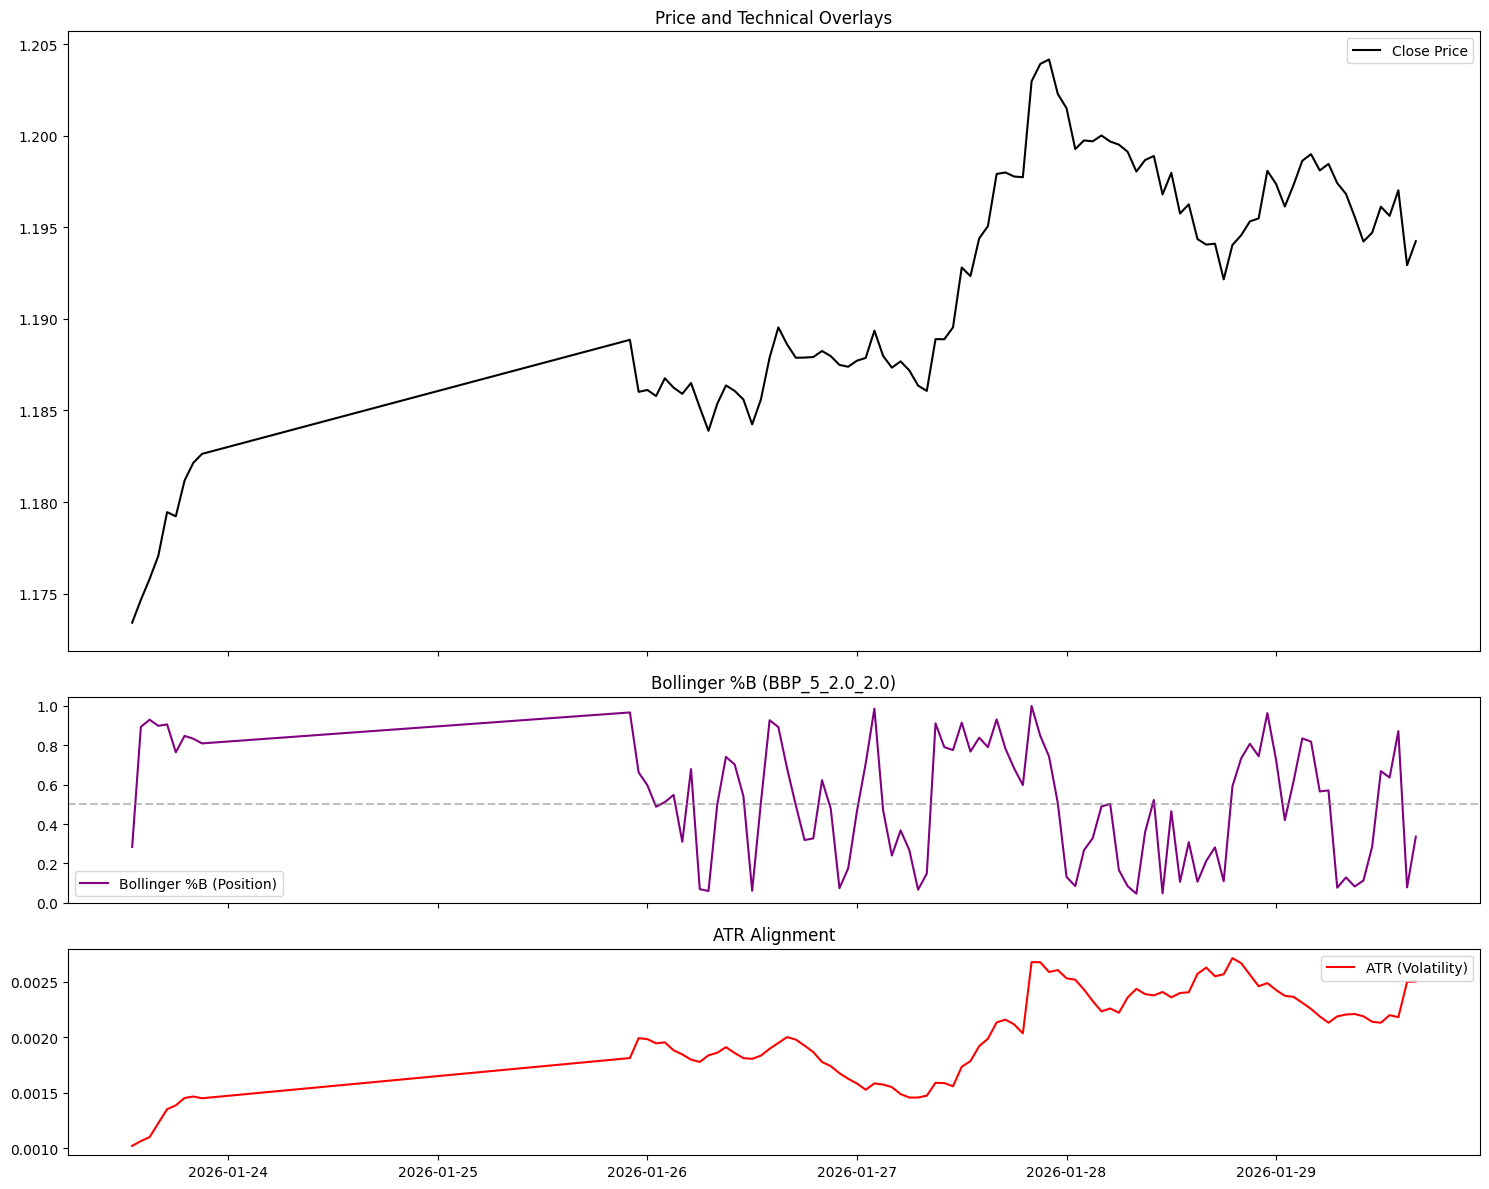

In [17]:
# Plot last 100 periods for visual confirmation of ATR and Bollinger Band features
plot_df = df.tail(100)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 12), sharex=True, gridspec_kw={'height_ratios': [3, 1, 1]})

# Price Plot
ax1.plot(plot_df.index, plot_df['Close'], label='Close Price', color='black')
ax1.set_title("Price and Technical Overlays")
ax1.legend()

# Bollinger %B (BBP) - Stationary relative position
bb_col = [c for c in df.columns if "BBP" in c][0] if any("BBP" in c for c in df.columns) else None
if bb_col:
    ax2.plot(plot_df.index, plot_df[bb_col], label='Bollinger %B (Position)', color='purple')
    ax2.axhline(0.5, linestyle='--', color='gray', alpha=0.5)
    ax2.set_title(f"Bollinger %B ({bb_col})")
    ax2.legend()

# ATR Plot
if 'ATRr_14' in df.columns:
    ax3.plot(plot_df.index, plot_df['ATRr_14'], label='ATR (Volatility)', color='red')
    ax3.set_title("ATR Alignment")
    ax3.legend()

plt.tight_layout()
plt.show()

### 4. Indicator Correlation Matrix

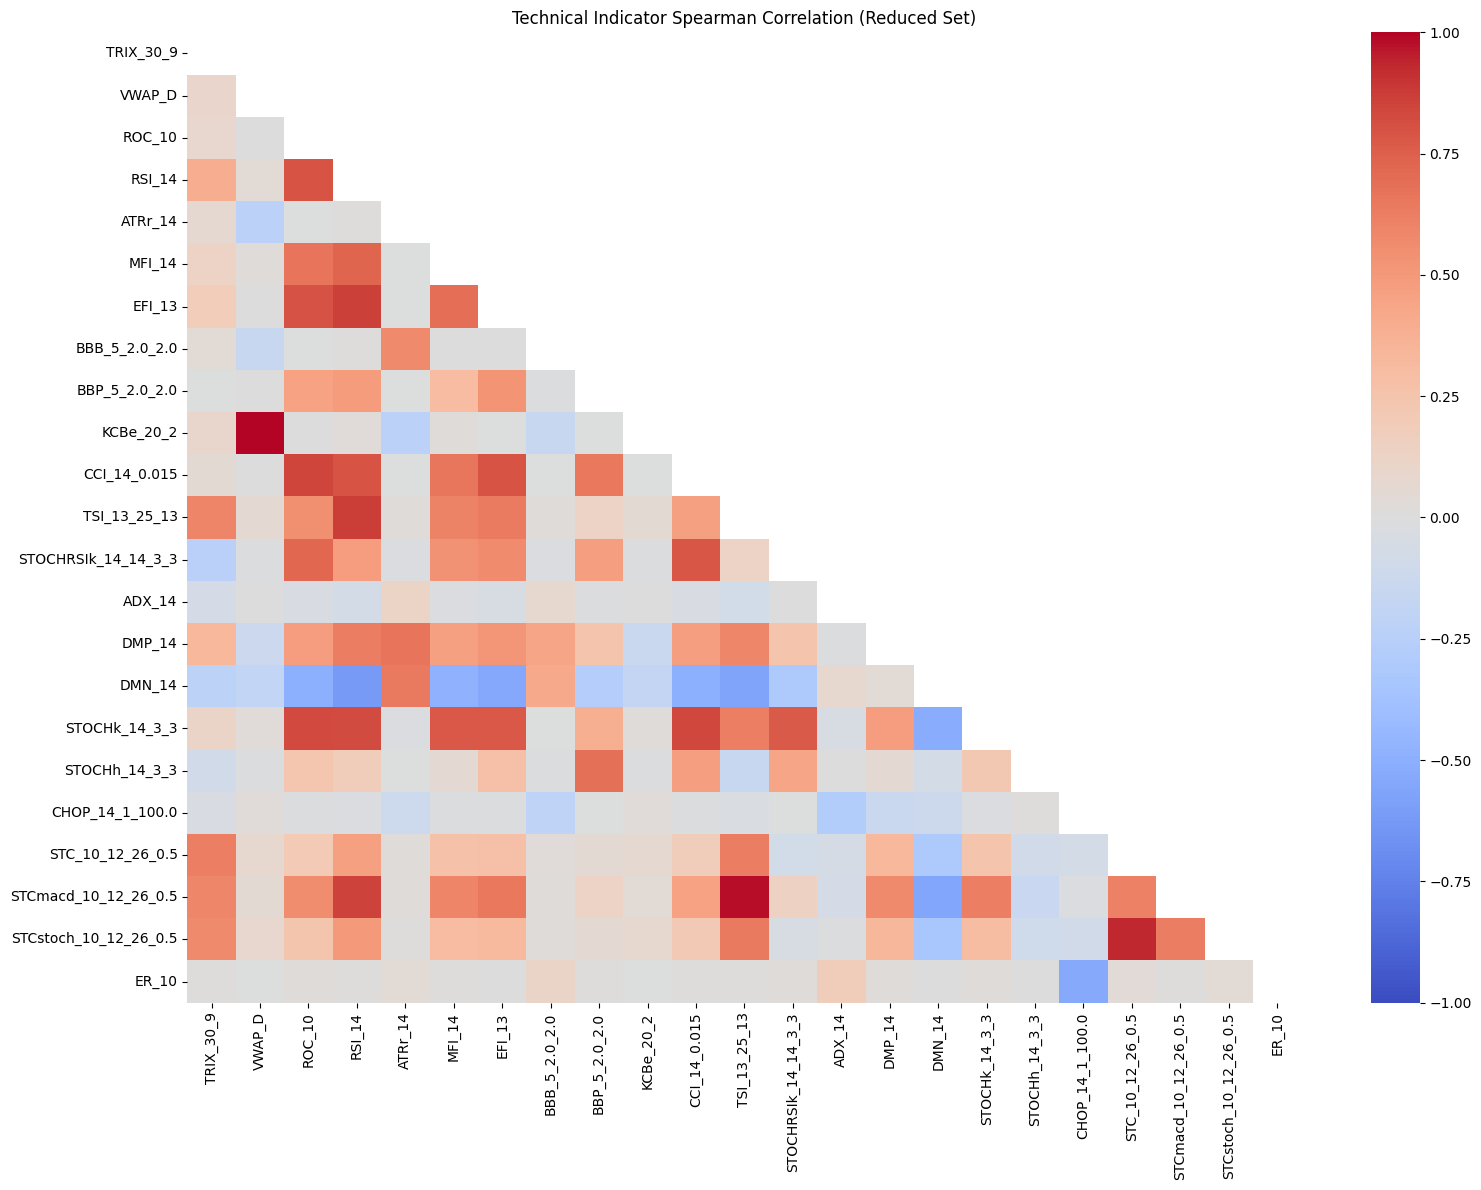

In [18]:
target_cols = [c for c in df.columns if "Target" in c or "LogRet" in c]
metadata_cols = ["Open", "High", "Low", "Close", "Volume"]
indicator_cols = [col for col in df.columns if col not in target_cols and col not in metadata_cols]

plt.figure(figsize=(16, 12))
corr_matrix = df[indicator_cols].corr(method="spearman")
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Technical Indicator Spearman Correlation (Reduced Set)")
plt.tight_layout()
plt.show()